# Target Hit Analysis

Runs `analyze_target_hit.py` across all six combinations (All / S&P / Nasdaq
x Hit / Miss) in one place, instead of six separate terminal calls.

Edit `OUTPUT_FOLDER` below to point at your `parse_sessions.py` output
folder, then run all cells.

In [29]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent / "src"))

import analyze_target_hit as ath
from pathlib import Path

BASE_DIR = Path(r"C:\Git\CandleStateSessionAnalysis\data")
STRATEGY = "MACDTrail"  # "MACDTrail" or "MACDTarget" or "MACDFlip"

OUTPUT_FOLDER = BASE_DIR / STRATEGY / "output"

sessions, positions = ath.load_tables(OUTPUT_FOLDER)
print(f"{len(sessions)} sessions, {len(positions)} positions loaded")

91 sessions, 288 positions loaded


## All (S&P + Nasdaq combined)

How you actually trade -- no index filtering.

In [30]:
profile = ath.profile_target_hit_days(sessions, positions, None, target_hit=True)
ath.print_summary(profile, target_hit=True)

58 target-hit session(s)

One direction only: 40 (69%)
Flipped direction:  18 (31%)

Position count distribution:
PositionCount
1     2
2    38
3     9
4     6
5     2
6     1

Direction combination counts:
                          Count      TotalPL       AvgPL
Directions                                              
Long                         24  5901.598492  245.899937
Short                        16  5812.974125  363.310883
Short, Long                  10  4680.057948  468.005795
Long, Short, Long             3  1526.625366  508.875122
Long, Short                   2  1051.575964  525.787982
Short, Long, Short, Long      2  -194.954043  -97.477022
Short, Long, Short            1   639.606490  639.606490

                                    SourceFile  AccountName  PositionCount                          Symbols               Directions  Flipped  RealizedPL
Session_File__2026-03-03__2026-07-09_0852.json Test Account              3                  SDS, UPRO, TQQQ              Shor

In [31]:
profile = ath.profile_target_hit_days(sessions, positions, None, target_hit=False)
ath.print_summary(profile, target_hit=False)

33 target-missed session(s)

One direction only: 1 (3%)
Flipped direction:  32 (97%)

Position count distribution:
PositionCount
2     1
3     9
4     7
5    12
6     2
7     2

Direction combination counts:
                                Count      TotalPL       AvgPL
Directions                                                    
Long, Short                        11  -266.336058  -24.212369
Short, Long, Short                  8 -3615.910115 -451.988764
Short, Long, Short, Long            4  -305.320372  -76.330093
Long, Short, Long                   3 -1361.316653 -453.772218
Short, Long                         3  -724.449125 -241.483042
Long, Short, Long, Short, Long      2 -1944.548528 -972.274264
Long, Short, Long, Short            1  -259.526649 -259.526649
Short                               1  -287.295032 -287.295032

                                    SourceFile  AccountName  PositionCount                               Symbols                     Directions  Flipped  Realize

## S&P only (UPRO/SDS)

In [32]:
profile = ath.profile_target_hit_days(sessions, positions, ath.INDEX_SYMBOLS["S"], target_hit=True)
ath.print_summary(profile, target_hit=True)

56 target-hit session(s)

One direction only: 39 (70%)
Flipped direction:  17 (30%)

Position count distribution:
PositionCount
1    39
2    13
3     3
4     1

Direction combination counts:
                          Count      TotalPL       AvgPL
Directions                                              
Long                         23  1993.121871   86.657473
Short                        16  2557.894857  159.868429
Short, Long                  11  1943.114923  176.646811
Long, Short, Long             3   401.294092  133.764697
Long, Short                   2   337.407594  168.703797
Short, Long, Short, Long      1    23.578402   23.578402

                                    SourceFile  AccountName  PositionCount              Symbols               Directions  Flipped  RealizedPL
Session_File__2026-03-03__2026-07-09_0852.json Test Account              2            SDS, UPRO              Short, Long     True  921.622984
Session_File__2026-03-05__2026-07-09_0853.json Test Account         

In [33]:
profile = ath.profile_target_hit_days(sessions, positions, ath.INDEX_SYMBOLS["S"], target_hit=False)
ath.print_summary(profile, target_hit=False)

33 target-missed session(s)

One direction only: 4 (12%)
Flipped direction:  29 (88%)

Position count distribution:
PositionCount
1     4
2    18
3     9
4     2

Direction combination counts:
                          Count     TotalPL       AvgPL
Directions                                             
Long, Short                  14  603.002920   43.071637
Short, Long, Short            6 -281.423283  -46.903880
Short, Long                   4  -96.965098  -24.241275
Short                         4  -73.349294  -18.337324
Long, Short, Long             3 -612.539056 -204.179685
Short, Long, Short, Long      2 -139.171591  -69.585796

                                    SourceFile  AccountName  PositionCount              Symbols               Directions  Flipped  RealizedPL
Session_File__2026-03-02__2026-07-09_0852.json Test Account              2            SDS, UPRO              Short, Long     True  -54.335055
Session_File__2026-03-04__2026-07-09_0852.json Test Account              3

## Nasdaq only (TQQQ/QID)

In [34]:
profile = ath.profile_target_hit_days(sessions, positions, ath.INDEX_SYMBOLS["N"], target_hit=True)
ath.print_summary(profile, target_hit=True)

58 target-hit session(s)

One direction only: 52 (90%)
Flipped direction:  6 (10%)

Position count distribution:
PositionCount
1    52
2     3
3     3

Direction combination counts:
                    Count      TotalPL       AvgPL
Directions                                        
Long                   36  7864.325170  218.453477
Short                  16  3870.212063  241.888254
Short, Long             2    74.623652   37.311826
Long, Short, Long       2    12.876913    6.438456
Long, Short             1   314.561110  314.561110
Short, Long, Short      1    24.473695   24.473695

                                    SourceFile  AccountName  PositionCount         Symbols         Directions  Flipped  RealizedPL
Session_File__2026-03-03__2026-07-09_0852.json Test Account              1            TQQQ               Long    False  754.474230
Session_File__2026-03-05__2026-07-09_0853.json Test Account              1             QID              Short    False  192.498444
Session_File__20

In [35]:
profile = ath.profile_target_hit_days(sessions, positions, ath.INDEX_SYMBOLS["N"], target_hit=False)
ath.print_summary(profile, target_hit=False)

33 target-missed session(s)

One direction only: 10 (30%)
Flipped direction:  23 (70%)

Position count distribution:
PositionCount
1     9
2    18
3     3
4     1
5     2

Direction combination counts:
                                Count      TotalPL       AvgPL
Directions                                                    
Short, Long                        10 -2160.985531 -216.098553
Long                                7  -456.370586  -65.195798
Long, Short                         7 -2156.379099 -308.054157
Short                               3  -231.795842  -77.265281
Short, Long, Short                  2  -799.270675 -399.635337
Long, Short, Long, Short, Long      2 -1675.179998 -837.589999
Long, Short, Long                   1  -467.052366 -467.052366
Short, Long, Short, Long            1  -217.223033 -217.223033

                                    SourceFile  AccountName  PositionCount                    Symbols                     Directions  Flipped  RealizedPL
Session_File_

## Visualization (optional)

Uses `visualize_target_hit.py`'s combined hit/miss profile -- same data as
above, plotted instead of printed. Delete this section if you just want
the six text summaries above.

Saved C:\Git\CandleStateSessionAnalysis\data\MACDTrail\output\target_hit_visualization.png


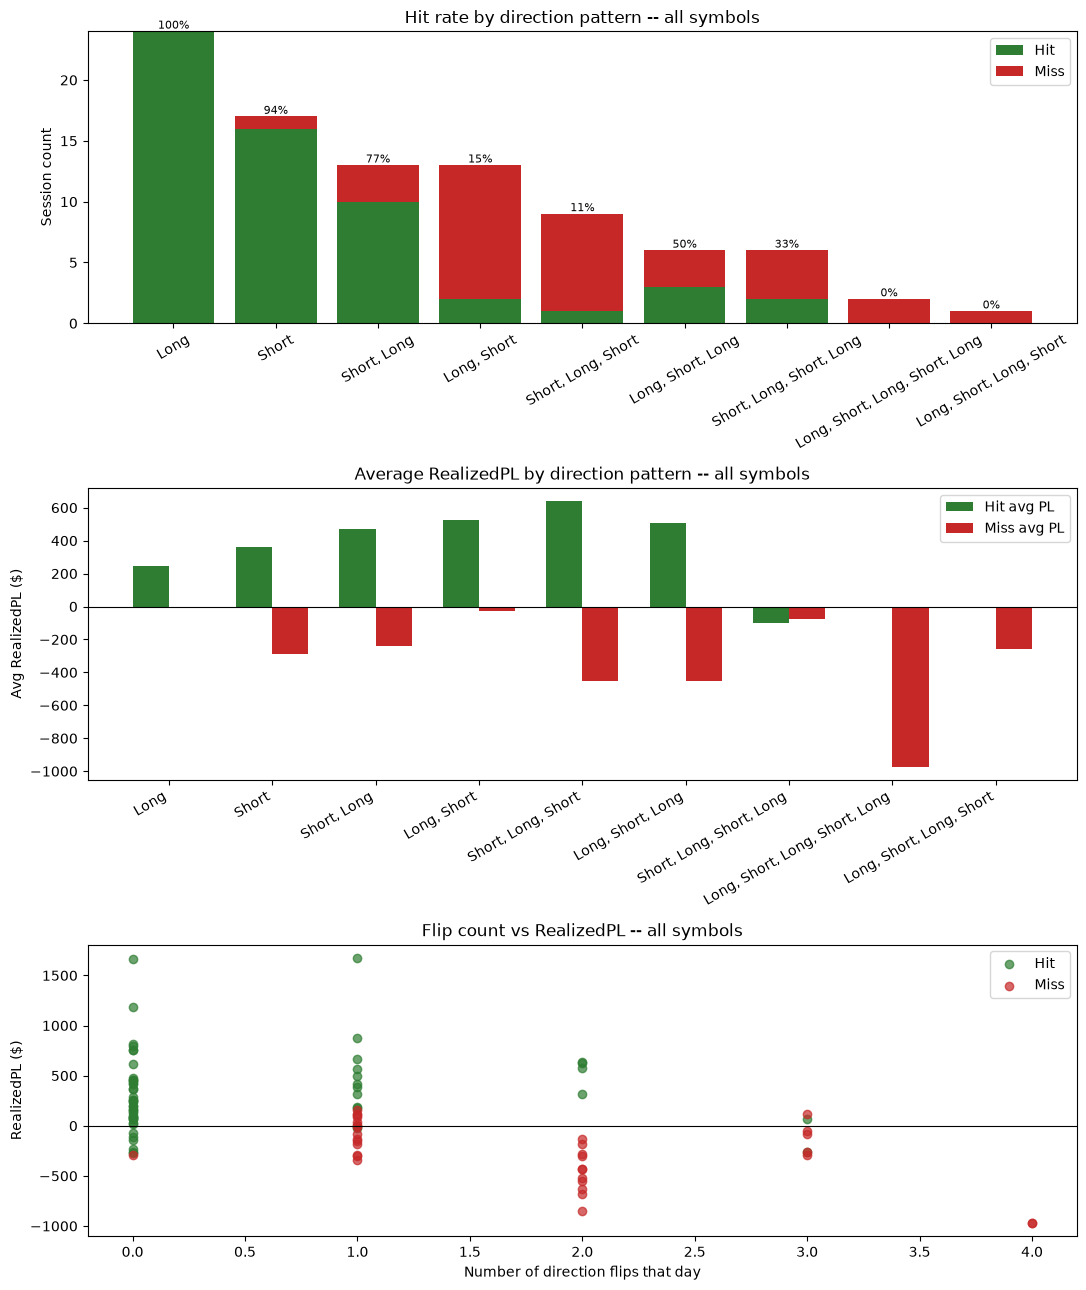

In [36]:
%matplotlib inline
import visualize_target_hit as vth

full_profile = vth.build_full_profile(sessions, positions, None)
vth.plot_profile(full_profile, "all symbols", OUTPUT_FOLDER / "target_hit_visualization.png")

                                    SourceFile  TargetHit  PositionCount               Directions  NumFlips  RealizedPL        SessionStart  CumulativePL  DayIndex
Session_File__2026-05-01__2026-07-09_0855.json      False              3              Long, Short         1   87.452067 2026-05-01 09:30:00   5308.025782        36
Session_File__2026-05-04__2026-07-09_0855.json      False              5 Short, Long, Short, Long         3 -291.373548 2026-05-04 09:30:00   5016.652234        37
Session_File__2026-05-05__2026-07-09_0855.json      False              3              Long, Short         1   35.991428 2026-05-05 09:30:00   5052.643662        38
Session_File__2026-05-06__2026-07-09_0855.json       True              3              Long, Short         1  382.089411 2026-05-06 09:30:00   5434.733073        39
Saved C:\Git\CandleStateSessionAnalysis\data\MACDTrail\output\target_hit_equity_curves.png


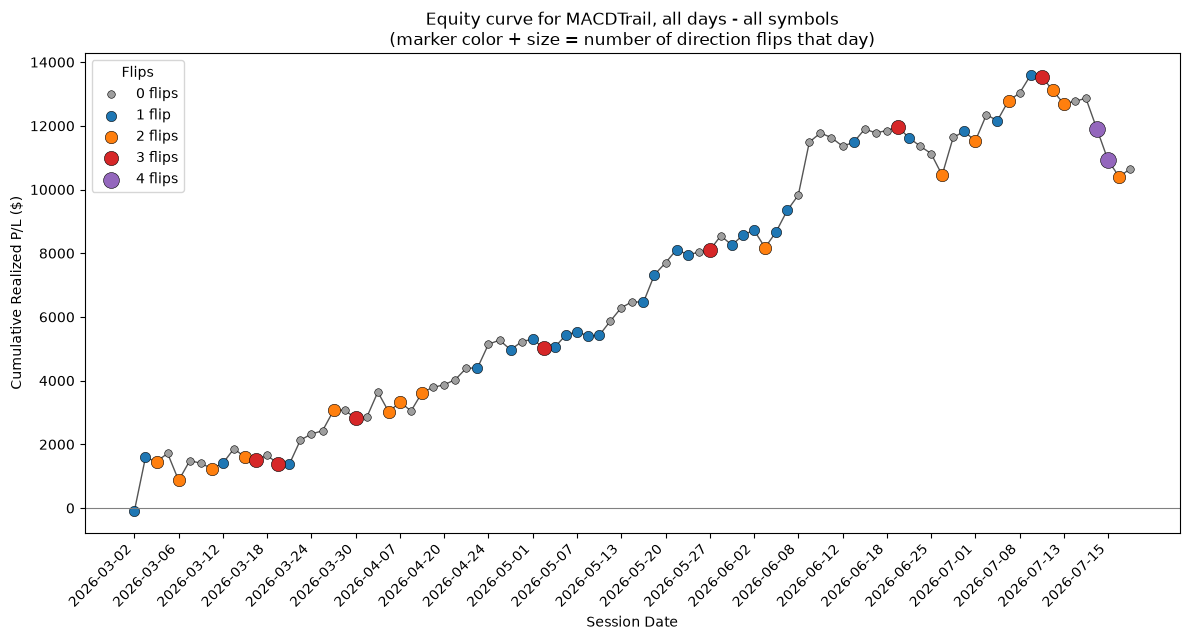

In [37]:
equity_curves = vth.build_equity_curves(sessions, positions, None)

mask = (equity_curves["SessionStart"] >= "2026-05-01") & (equity_curves["SessionStart"] <= "2026-05-07")
print(equity_curves[mask].to_string(index=False))

vth.plot_equity_curves(equity_curves, "all symbols", OUTPUT_FOLDER / "target_hit_equity_curves.png", STRATEGY)